In [1]:
import psycopg2 as pg
import pandas as pd
import math
import numpy as np
import pandas.io.sql as psql

In [793]:
connection = pg.connect("host=localhost dbname=Simulacred user=postgres password=12345678")

In [ ]:
connection.close()

### Importação das Views do Postgre

In [374]:
#carteira
agg = psql.read_sql('SELECT * FROM jpcosta.perda_obs_atr', connection)

In [375]:
#Série de TD
serie_pd_2 = psql.read_sql('SELECT * FROM jpcosta.calculo_pd_2', connection)

In [376]:
#serie de LGD
lgd_i = psql.read_sql('SELECT * FROM jpcosta.calculo_lgd60', connection)

In [377]:
df1 = serie_pd_2[['ref', 'porte', 'modalidade', 'qtd', 'qtd_inad']].groupby(['ref', 'porte', 'modalidade']).sum().reset_index()

probd = df1['qtd_inad']/df1['qtd']

df1['pd'] = probd

### Cálculo PD

In [509]:
pd_model = df1[(df1['ref'] > 0) & ((df1['ref'] < 48))].drop('ref', axis=1).groupby(['porte', 'modalidade'])\
            .mean().reset_index().drop(['qtd', 'qtd_inad'], axis=1)
pd_model

,porte,modalidade,pd
0,1,1,0.20434544952723582
1,1,2,0.1376708692589457
2,1,3,0.10355575881584488
3,1,4,0.06293166196415345
4,2,1,0.16559432283245606
5,2,2,0.10554935104276306
6,2,3,0.07228007984606388
7,2,4,0.02892996280999309
8,3,1,0.14034102489771547
9,3,2,0.08601895564877157


In [510]:
pd_monit = df1[df1['ref'].between(72, 84)].drop('ref', axis=1).groupby(['porte', 'modalidade']).mean().reset_index()
pd_monit = pd_monit.rename(columns={'pd': 'pd_monit'}).drop(['qtd', 'qtd_inad'], axis=1)
pd_monit



,porte,modalidade,pd_monit
0,1,1,0.32006694295952987
1,1,2,0.24487533127169464
2,1,3,0.2112061680893573
3,1,4,0.1689378260083814
4,2,1,0.28048172311964853
5,2,2,0.20575027263036152
6,2,3,0.16122825246782796
7,2,4,0.12410805232781041
8,3,1,0.24707576664861863
9,3,2,0.16738426369824905


<Figure size 432x288 with 0 Axes>

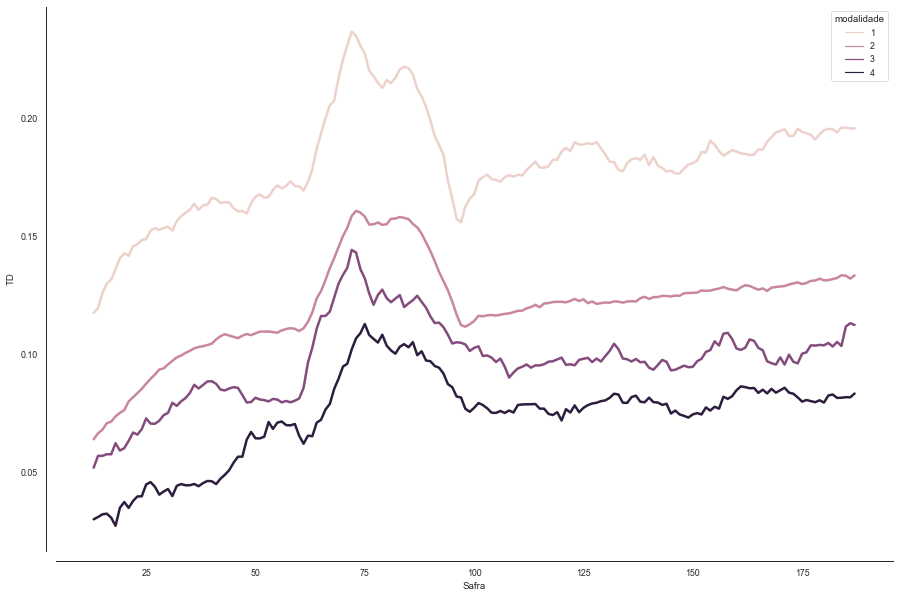

In [1034]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

sns.set_style("white")
sns.despine(left=True)

fig, ax = plt.subplots(figsize=(15,10))
# data to create an example data frame
df  = df1.groupby(['modalidade', 'ref']).mean()

# this is to plot the kde
sns.lineplot(data=df.reset_index()[df.reset_index()['ref'] > 12], x='ref', y = 'pd',  hue='modalidade', linewidth=2.5)

sns.despine(offset=10, trim=False);

# beautifying the labels
plt.xlabel('Safra')
plt.ylabel('TD')
plt.show()

## Cálculo LGD

In [794]:
#serie de LGD
lgd_bst = psql.read_sql('SELECT * FROM jpcosta.calculo_lgd_bst', connection)

lgdbest = lgd_bst[lgd_bst.ref > 0].drop('ref', axis=1).groupby(['modalidade', 'fx_atraso']).mean('lgd').reset_index()
lgdbest

,modalidade,fx_atraso,lgd
0,1,1,0.5870811196524842
1,1,2,0.6634752895962129
2,1,3,0.7459526179454199
3,1,4,0.9477174682155745
4,2,1,0.5424299245076102
5,2,2,0.6294184190733152
6,2,3,0.7343029198911358
7,2,4,0.9300521237428334
8,3,1,0.4871110466595233
9,3,2,0.6042140486162623


In [511]:
ecl = pd_model.merge(lgd.drop(['porte'], axis=1), on=['modalidade'], how='left').fillna(0.500)
ecl['ecl'] = ecl['pd'] * ecl['lgd']
ecl = ecl.merge(pd_monit, on=['porte', 'modalidade'], how='left')
ecl['ecl2'] = ecl['pd_monit'] * ecl['lgd']

ecl

,porte,modalidade,pd,lgd,ecl,pd_monit,ecl2
0,1,1,0.20434544952723582,0.5957664462734151,0.1217421622769848,0.32006694295952987,0.19068514517659496
1,1,2,0.1376708692589457,0.5516991470154226,0.0759529011390321,0.24487533127169464,0.13509751138771295
2,1,3,0.10355575881584488,0.5003211349501125,0.05181113478136363,0.2112061680893573,0.10567090972693148
3,1,4,0.06293166196415345,0.38078550256522115,0.023963464528284784,0.1689378260083814,0.0643290749788774
4,2,1,0.16559432283245606,0.5957664462734151,0.09865554123694499,0.28048172311964853,0.16710159942763697
5,2,2,0.10554935104276306,0.5516991470154226,0.05823148693832378,0.20575027263036152,0.11351224990836109
6,2,3,0.07228007984606388,0.5003211349501125,0.036163251582867435,0.16122825246782796,0.08066590226072697
7,2,4,0.02892996280999309,0.38078550256522115,0.011016110427796376,0.12410805232781041,0.047258547078036055
8,3,1,0.14034102489771547,0.5957664462734151,0.08361047366968082,0.24707576664861863,0.1471994514565271
9,3,2,0.08601895564877157,0.5516991470154226,0.04745658445858474,0.16738426369824905,0.09234575550612856


### Carteira de Crédito

In [384]:
dict_prov = {  'AA': 0.00,
               'A' : 0.005,
               'B':  0.01,
               'C':  0.03,
               'D':  0.10,
               'E':  0.30,
               'F':  0.50,
               'G':  0.70,
               'H':  1.00,
               'HH': 0.00}   

In [618]:
df2 = agg[['ref', 'nivel_risco','fx_atraso' , 'porte', 'qtd','modalidade', 'estagio', 'saldo', 'saldo_inad', 'perda_att']]\
        .groupby(['ref', 'nivel_risco', 'fx_atraso' ,'porte', 'modalidade', 'estagio']).sum().reset_index()

df2['prov'] = df2['nivel_risco'].map(dict_prov)*df2['saldo']

df2 = df2.merge(ecl, how='left', on=['porte', 'modalidade'])

df2

,ref,nivel_risco,fx_atraso,porte,modalidade,estagio,qtd,saldo,saldo_inad,perda_att,prov,pd,lgd,ecl,pd_monit,ecl2
0,0,A,1,1,1,1,1,3533.16,0.0,0.0,17.6658,0.20434544952723582,0.5957664462734151,0.1217421622769848,0.32006694295952987,0.19068514517659496
1,0,A,1,1,2,1,2,4282.42,0.0,0.0,21.412100000000002,0.1376708692589457,0.5516991470154226,0.0759529011390321,0.24487533127169464,0.13509751138771295
2,0,A,1,1,3,1,1,29133.97,0.0,0.0,145.66985,0.10355575881584488,0.5003211349501125,0.05181113478136363,0.2112061680893573,0.10567090972693148
3,0,A,1,2,3,1,1,38057.07,0.0,0.0,190.28535,0.07228007984606388,0.5003211349501125,0.036163251582867435,0.16122825246782796,0.08066590226072697
4,0,A,1,3,1,1,1,6524.94,0.0,0.0,32.6247,0.14034102489771547,0.5957664462734151,0.08361047366968082,0.24707576664861863,0.1471994514565271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50743,200,HH,4,5,4,3,89,35635459.3,0.0,0.0,0.0,0.04372239603597523,0.38078550256522115,0.01664885454791446,0.08454563259797951,0.03219375119851617
50744,200,HH,4,6,1,3,1153,18230854.5,0.0,0.0,0.0,0.05828959136455944,0.5957664462734151,0.03472698270199313,0.0819951753081234,0.048849974204886355
50745,200,HH,4,6,2,3,4168,27772236.95,0.0,0.0,0.0,0.026709642264489894,0.5516991470154226,0.014735686854406153,0.06003477400907582,0.033121133612070794
50746,200,HH,4,6,3,3,171,3153727.66,0.0,0.0,0.0,0.02835689389738057,0.5003211349501125,0.014187553338397368,0.057592153536996656,0.028814571621851304


In [619]:
prob = []

for i in range(len(df2)):
    if df2.estagio[i] == 1:
        prob.append(df2.pd[i])
    elif df2.estagio[i] == 2:
        
        b = (0.11852 - 0.05478*math.log(max(0.003, df2.pd[i])))**2
        m = (1 + (3 - 2.5) * b)/(1 - (1.5) * b)
        
        prob.append(df2.pd[i]*m)
        
    else:
        prob.append(1.00)

df2['pd'] = prob

df2['ecl'] = df2['pd'] * df2['lgd'] * df2['saldo']
#agg['ecl2'] = agg['pd_monit'] * agg['lgd'] * agg['saldo']

In [387]:
hst = df2[df2['nivel_risco'] != 'HH'][['ref', 'saldo', 'saldo_inad', 'prov', 'ecl', 'ecl2', 'perda_att']].groupby(['ref']).sum(['prov', 'saldo', 'ecl', 'perda_att'])

In [388]:
hst['iprov'] = hst['prov']/hst['saldo']
hst['inad90'] = hst['saldo_inad']/hst['saldo']
hst['iPE'] = hst['ecl']/hst['saldo']
hst['perda_obs'] = hst['perda_att']/hst['saldo']
hst['dif'] = hst['iPE'] - hst['iprov']

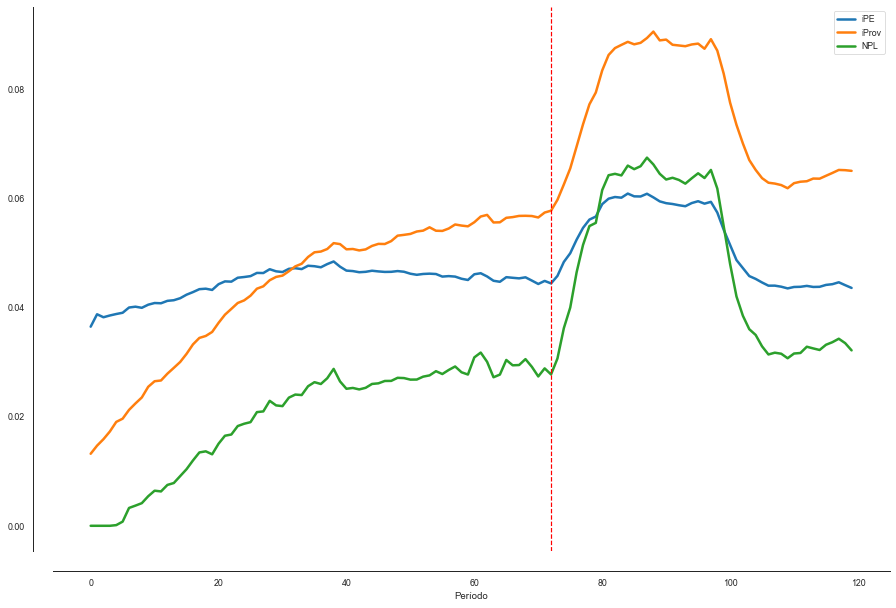

In [1002]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.color_palette("ch:s=.25,rot=-.25", as_cmap=True)

sns.set_style("white")
sns.set_context("paper")


#sns.set_style()
%matplotlib inline
fig, ax = plt.subplots(figsize=(15,10))
# data to create an example data frame
df  = hst[['iPE','iprov','inad90', 'perda_obs']]#[60:n-82]

# this is to plot the kde
sns.lineplot(data=df[:120], x='ref', y = 'iPE', label='iPE', linewidth=2.5)
sns.lineplot(data=df[:120], x='ref', y = 'iprov', label='iProv', linewidth=2.5)
sns.lineplot(data=df[:120], x='ref', y = 'inad90', label='NPL', linewidth=2.5)
#sns.lineplot(data=df[:120], x='ref', y = 'perda_obs', label='PO')

sns.despine(offset=20, trim=False);

ax.axvline(72, ls='--', c='red')

# beautifying the labels
plt.xlabel('Período')
plt.ylabel('')
plt.show()

In [392]:
n = agg.ref.max()

In [620]:
df3 = df1.sort_values(['porte', 'modalidade', 'ref']).merge(pd_monit[['porte', 'modalidade', 'pd_monit']], how='left', on=['modalidade', 'porte'])
df3 = df3.merge(pd_model[['porte', 'modalidade', 'pd']].rename(columns={'pd':'pd_model'}), how='left', on=['modalidade', 'porte'])

df3['td'] = df3.groupby(['porte','modalidade'])['pd'].shift(12)
df3['PD_12'] = df3.groupby(['porte','modalidade']).rolling(window=12)['td'].mean().reset_index()['td']
df3['PD_24'] = df3.groupby(['porte','modalidade']).rolling(window=24)['td'].mean().reset_index()['td']
df3['PD_36'] = df3.groupby(['porte','modalidade']).rolling(window=36)['td'].mean().reset_index()['td']
df3['PD_48'] = df3.groupby(['porte','modalidade']).rolling(window=48)['td'].mean().reset_index()['td']

In [621]:
prob, prob0, prob1, prob2, prob3, prob4, prob5 = [], [], [], [], [], [], []

agg2 = df2[df2.ref <= max(df3.ref)]

for i in range(len(agg2)):
    p  = df3[(df3.ref == agg2.ref[i]) & (df3.modalidade == agg2.modalidade[i]) & (df3.porte == agg2.porte[i])].pd_model.values[0]
    p0 = df3[(df3.ref == agg2.ref[i]) & (df3.modalidade == agg2.modalidade[i]) & (df3.porte == agg2.porte[i])].td.values[0]
    p1 = df3[(df3.ref == agg2.ref[i]) & (df3.modalidade == agg2.modalidade[i]) & (df3.porte == agg2.porte[i])].PD_12.values[0]
    p2 = df3[(df3.ref == agg2.ref[i]) & (df3.modalidade == agg2.modalidade[i]) & (df3.porte == agg2.porte[i])].PD_24.values[0]
    p3 = df3[(df3.ref == agg2.ref[i]) & (df3.modalidade == agg2.modalidade[i]) & (df3.porte == agg2.porte[i])].PD_36.values[0]
    p4 = df3[(df3.ref == agg2.ref[i]) & (df3.modalidade == agg2.modalidade[i]) & (df3.porte == agg2.porte[i])].PD_48.values[0]
    p5 = df3[(df3.ref == agg2.ref[i]) & (df3.modalidade == agg2.modalidade[i]) & (df3.porte == agg2.porte[i])].pd_monit.values[0]
  
    if agg2.estagio[i] == 1:
        prob.append(p)
        prob0.append(p0)
        prob1.append(p1)
        prob2.append(p2)
        prob3.append(p3)
        prob4.append(p4)
        prob5.append(p5)       
        
    elif agg2.estagio[i] == 2:
        
        b = (0.11852 - 0.05478*math.log(max(0.003, p)))**2          
        b0 = (0.11852 - 0.05478*math.log(max(0.003, p0)))**2     
        b1 = (0.11852 - 0.05478*math.log(max(0.003, p1)))**2
        b2 = (0.11852 - 0.05478*math.log(max(0.003, p2)))**2
        b3 = (0.11852 - 0.05478*math.log(max(0.003, p3)))**2
        b4 = (0.11852 - 0.05478*math.log(max(0.003, p4)))**2
        b5 = (0.11852 - 0.05478*math.log(max(0.003, p5)))**2
        
        m = (1 + (3 - 2.5) * b)/(1 - (1.5) * b)         
        m0 = (1 + (3 - 2.5) * b0)/(1 - (1.5) * b0)      
        m1 = (1 + (3 - 2.5) * b1)/(1 - (1.5) * b1)
        m2 = (1 + (3 - 2.5) * b2)/(1 - (1.5) * b2)
        m3 = (1 + (3 - 2.5) * b3)/(1 - (1.5) * b3)
        m4 = (1 + (3 - 2.5) * b4)/(1 - (1.5) * b4)
        m5 = (1 + (3 - 2.5) * b5)/(1 - (1.5) * b5)
        
        prob.append(p*m)        
        prob0.append(p0*m0)        
        prob1.append(p1*m1)
        prob2.append(p2*m2)
        prob3.append(p3*m3)
        prob4.append(p4*m4)
        prob5.append(p5*m5)
        
    else:
        
        prob.append(1.00)       
        prob0.append(1.00)
        prob1.append(1.00)
        prob2.append(1.00)
        prob3.append(1.00)  
        prob4.append(1.00)
        prob5.append(1.00)

agg2['pd'] = prob
agg2['td'] = prob0
agg2['pd_12'] = prob1
agg2['pd_24'] = prob2
agg2['pd_36'] = prob3
agg2['pd_48'] = prob4
agg2['pd_mnt'] = prob5

agg2['ecl'] = agg2['pd'] * agg2['lgd'] * agg2['saldo']
agg2['ecl2'] = agg2['pd_mnt'] * agg2['lgd'] * agg2['saldo']
agg2['ecl3'] = agg2['td'] * agg2['lgd'] * agg2['saldo']
agg2['ecl4'] = agg2['pd_12'] * agg2['lgd'] * agg2['saldo']
agg2['ecl5'] = agg2['pd_24'] * agg2['lgd'] * agg2['saldo']
agg2['ecl6'] = agg2['pd_36'] * agg2['lgd'] * agg2['saldo']
agg2['ecl7'] = agg2['pd_48'] * agg2['lgd'] * agg2['saldo']


<ipython-input-621-e6cf500479e5>:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg2['pd'] = prob
<ipython-input-621-e6cf500479e5>:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg2['td'] = prob0
<ipython-input-621-e6cf500479e5>:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-vie

In [622]:
hst2 = agg2[agg2['nivel_risco'] != 'HH'][['ref', 'saldo', 'saldo_inad', 'prov', 'ecl', 'ecl2','ecl3', 'ecl4','ecl5', 'ecl6', 'ecl7', 'perda_att']].groupby(['ref']).sum(['prov', 'saldo', 'ecl', 'perda_att'])

In [623]:
hst2['iprov'] = hst2['prov']/hst2['saldo']
hst2['inad90'] = hst2['saldo_inad']/hst['saldo']
hst2['iPE1'] = hst2['ecl']/hst['saldo']
hst2['iPE2'] = hst2['ecl2']/hst['saldo']
hst2['perda_obs'] = hst2['perda_att']/hst2['saldo']
#hst2['dif'] = hst2['iPE'] - hst2['iprov']

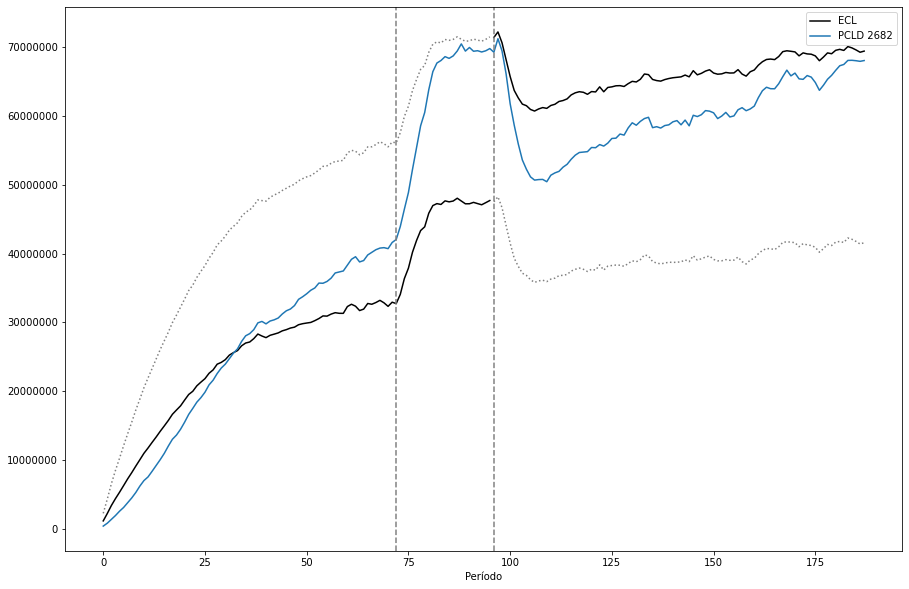

In [898]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax1 = plt.subplots(figsize=(15,10))
# data to create an example data frame
#ax2 = ax1.twinx() 
# this is to plot the kde
sns.lineplot(data=hst2[0:96], x='ref', y = 'ecl', color='black', ax = ax1, label='ECL')
sns.lineplot(data=hst2[96:], x='ref', y = 'ecl', linestyle='dotted', color='grey', ax = ax1)
sns.lineplot(data=hst2[0:96], x='ref', y = 'ecl2', linestyle='dotted', color='grey', ax = ax1)
sns.lineplot(data=hst2[96:], x='ref', y = 'ecl2', color='black', ax = ax1)
sns.lineplot(data=hst2, x='ref', y = 'prov',  ax = ax1, label='PCLD 2682')
#sns.lineplot(data=df1[60:148][df1['ref_r'].between(60, 148, inclusive='both')], x='ref_r', y = 'pd', ax = ax2)

#sns.lineplot(data=hst2[60:156], x='ref', y = 'ecl3', linestyle='dashed', color='orange', ax = ax1)
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl4', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl5', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl6', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl7', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'prov', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'perda_att', linestyle='dashed')

plt.ticklabel_format(style='plain', axis='y')

ax1.axvline(72, ls='--', c='grey')
ax1.axvline(96, ls='--', c='grey')


# beautifying the labels
plt.xlabel('Período')
plt.ylabel('')
plt.show()

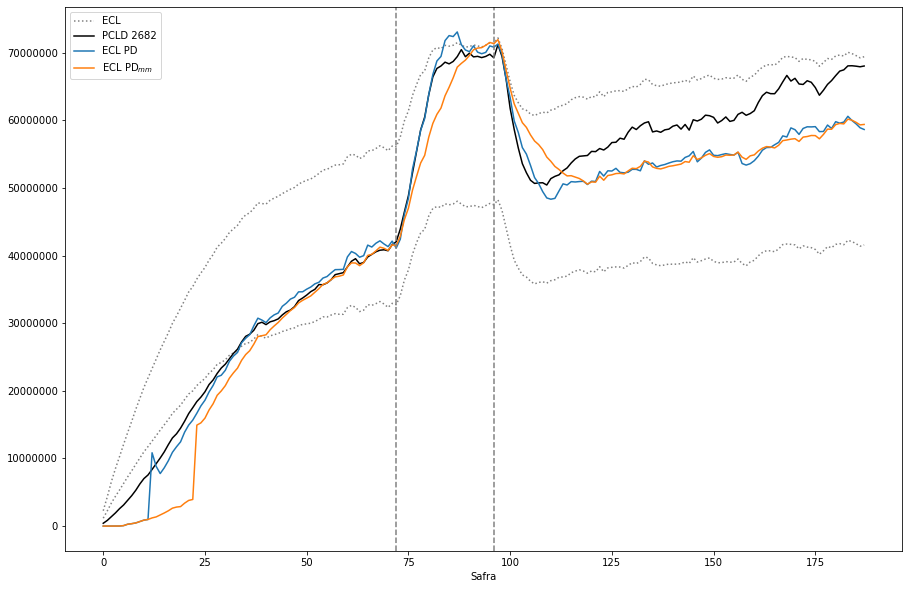

In [906]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax1 = plt.subplots(figsize=(15,10))
# data to create an example data frame
#ax2 = ax1.twinx() 
# this is to plot the kde
sns.lineplot(data=hst2, x='ref', y = 'ecl', linestyle='dotted', color='grey', ax = ax1, label='ECL')
sns.lineplot(data=hst2, x='ref', y = 'ecl2', linestyle='dotted', color='grey', ax = ax1)
sns.lineplot(data=hst2, x='ref', y = 'prov', color='black', ax = ax1, label='PCLD 2682')
sns.lineplot(data=hst2, x='ref', y = 'ecl3',  ax = ax1, label='ECL PD')
sns.lineplot(data=hst2, x='ref', y = 'ecl4',  ax = ax1, label='ECL PD$_{mm}$')
#sns.lineplot(data=df1[60:148][df1['ref_r'].between(60, 148, inclusive='both')], x='ref_r', y = 'pd', ax = ax2)

#sns.lineplot(data=hst2[60:156], x='ref', y = 'ecl3', linestyle='dashed', color='orange', ax = ax1)
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl4', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl5', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl6', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl7', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'prov', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'perda_att', linestyle='dashed')

plt.ticklabel_format(style='plain', axis='y')
ax1.axvline(72, ls='--', c='grey')
ax1.axvline(96, ls='--', c='grey')


# beautifying the labels
plt.xlabel('Safra')
plt.ylabel('')
plt.show()

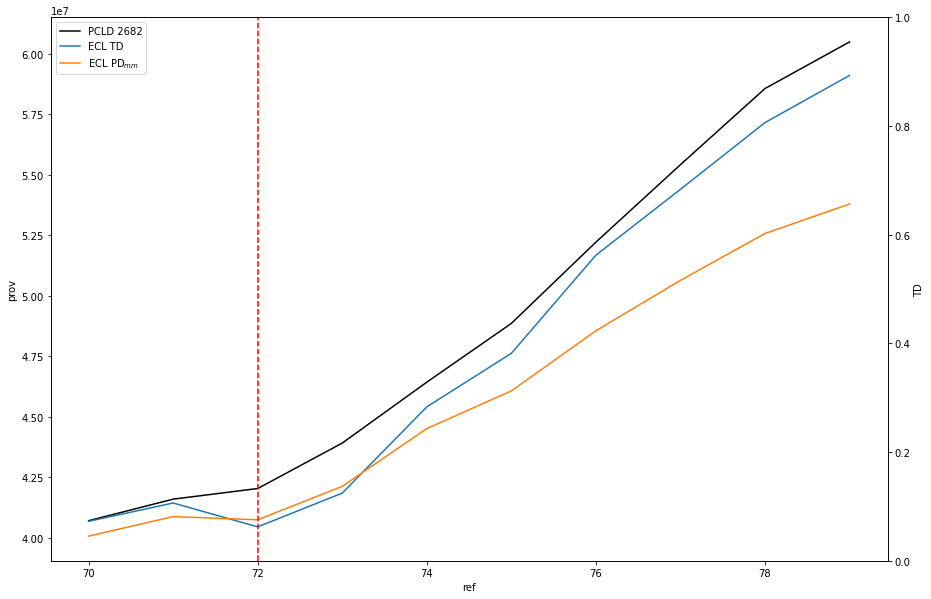

In [399]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax1 = plt.subplots(figsize=(15,10))
# data to create an example data frame
#ax2 = ax1.twinx() 
# this is to plot the kde
#sns.lineplot(data=hst2[65:75], x='ref', y = 'ecl', linestyle='dotted', color='grey', ax = ax1, label='ECL')
#sns.lineplot(data=hst2[65:75], x='ref', y = 'ecl2', linestyle='dotted', color='grey', ax = ax1)
sns.lineplot(data=hst2[70:80], x='ref', y = 'prov', color='black', ax = ax1, label='PCLD 2682')
sns.lineplot(data=hst2[70:80], x='ref', y = 'ecl3',  ax = ax1, label='ECL TD')
sns.lineplot(data=hst2[70:80], x='ref', y = 'ecl4',  ax = ax1, label='ECL PD$_{mm}$')
#sns.lineplot(data=hst2[70:80], x='ref', y = 'saldo_inad',  ax = ax2, label='NPL', color='green')
#sns.lineplot(data=df1[60:148][df1['ref_r'].between(60, 148, inclusive='both')], x='ref_r', y = 'pd', ax = ax2)

#sns.lineplot(data=hst2[60:156], x='ref', y = 'ecl3', linestyle='dashed', color='orange', ax = ax1)
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl4', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl5', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl6', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl7', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'prov', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'perda_att', linestyle='dashed')


ax1.axvline(72, ls='--', c='red')
#ax1.axvline(96, ls='--', c='grey')


# beautifying the labels
plt.xlabel('Safra')
plt.ylabel('R$')
plt.show()

## pool de atraso

In [532]:
serie_pd_2

,ref,porte,fx_atraso,modalidade,qtd,qtd_inad,pd,pool
0,0,1,1,4,21,0,0.0,010011
1,0,1,1,2,967,56,0.057911065149948295,010011
2,0,1,1,3,66,1,0.015151515151515152,010011
3,0,1,1,1,174,21,0.1206896551724138,010011
4,1,1,1,1,381,47,0.12335958005249344,010011
...,...,...,...,...,...,...,...,...
15332,184,6,4,2,1,1,1.0,040200
15333,184,6,4,1,1,1,1.0,040100
15334,185,6,4,2,2,2,1.0,040200
15335,186,6,4,2,3,2,0.6666666666666666,040200


In [569]:
#df4 = serie_pd_2.sort_values(['porte', 'modalidade', 'fx_atraso', 'ref'])
#df4['td'] = df4.groupby(['porte','modalidade', 'fx_atraso'])['pd'].shift(12)
#df4['PD_12'] = df4.groupby(['porte','modalidade', 'fx_atraso']).rolling(window=12)['td'].mean().reset_index()['td']

pool = []

for i in range(len(serie_pd_2)):
    if serie_pd_2.fx_atraso[i] == 1:
        pool.append('0' + str(serie_pd_2.fx_atraso[i]) + '0' + '0' + str(serie_pd_2.modalidade[i]) + str(serie_pd_2.porte[i]))
    else:
        pool.append('0' + str(serie_pd_2.fx_atraso[i]) + '0' + str(serie_pd_2.modalidade[i]) + '00')

len(pool)

15337

In [570]:
serie_pd_2['pool'] = pool

a = serie_pd_2[serie_pd_2['fx_atraso'] != 4]
a

,ref,porte,fx_atraso,modalidade,qtd,qtd_inad,pd,pool
0,0,1,1,4,21,0,0.0,010041
1,0,1,1,2,967,56,0.057911065149948295,010021
2,0,1,1,3,66,1,0.015151515151515152,010031
3,0,1,1,1,174,21,0.1206896551724138,010011
4,1,1,1,1,381,47,0.12335958005249344,010011
...,...,...,...,...,...,...,...,...
15155,186,6,3,2,21,18,0.8571428571428571,030200
15156,186,6,3,3,2,1,0.5,030300
15157,187,6,3,2,35,30,0.8571428571428571,030200
15158,187,6,3,4,2,2,1.0,030400


In [535]:
pool = []

for i in range(len(agg)):
    if agg.fx_atraso[i] == 1:
        pool.append('0' + str(agg.fx_atraso[i]) + '0' + '0' + str(agg.modalidade[i]) + str(agg.porte[i]))
    else:
        pool.append('0' + str(agg.fx_atraso[i]) + '0' + str(agg.modalidade[i]) + '00')

len(pool)

50748

In [536]:
agg['pool'] = pool

In [571]:
a = a.sort_values(['pool', 'ref'])
a['td'] =  a.groupby(['pool'])['pd'].shift(12)
a['PD_12'] = a.groupby(['pool']).rolling(window=12)['td'].mean().reset_index()['td']

a = a[['ref', 'pool', 'fx_atraso', 'qtd', 'qtd_inad']].groupby(['pool','fx_atraso', 'ref']).sum().reset_index()
p = a['qtd_inad']/a['qtd']

a['pd'] = p
a

,pool,fx_atraso,ref,qtd,qtd_inad,pd
0,010011,1,0,174,21,0.1206896551724138
1,010011,1,1,381,47,0.12335958005249344
2,010011,1,2,575,68,0.11826086956521739
3,010011,1,3,748,88,0.11764705882352941
4,010011,1,4,932,119,0.1276824034334764
...,...,...,...,...,...,...
5979,030400,3,183,74,58,0.7837837837837838
5980,030400,3,184,85,59,0.6941176470588235
5981,030400,3,185,85,61,0.7176470588235294
5982,030400,3,186,85,63,0.7411764705882353


In [1006]:
a = a.sort_values(['pool', 'ref'])
a['td'] = a.groupby(['pool'])['pd'].shift(12)
a['PD_12'] = a.groupby(['pool']).rolling(window=12)['td'].mean().reset_index()['td']
a['PD_24'] = a.groupby(['pool']).rolling(window=24)['td'].mean().reset_index()['td']
a

,pool,fx_atraso,ref,qtd,qtd_inad,pd,td,PD_12,PD_24
0,010011,1,0,174,21,0.1206896551724138,nan,nan,nan
1,010011,1,1,381,47,0.12335958005249344,nan,nan,nan
2,010011,1,2,575,68,0.11826086956521739,nan,nan,nan
3,010011,1,3,748,88,0.11764705882352941,nan,nan,nan
4,010011,1,4,932,119,0.1276824034334764,nan,nan,nan
...,...,...,...,...,...,...,...,...,...
5979,030400,3,183,74,58,0.7837837837837838,0.7835051546391752,0.7519284696534726,0.7360253739824154
5980,030400,3,184,85,59,0.6941176470588235,0.7307692307692307,0.7482719149405798,0.7360686865257279
5981,030400,3,185,85,61,0.7176470588235294,0.7411764705882353,0.747291522783717,0.7371891347049996
5982,030400,3,186,85,63,0.7411764705882353,0.7065217391304348,0.7367238899334755,0.735377540502101


In [542]:
l = agg[['modalidade', 'pool']].drop_duplicates().merge(lgd, how='left', on='modalidade')[['pool', 'lgd']]
l

,pool,lgd
0,010011,0.5957664462734151
1,010021,0.5516991470154226
2,010031,0.5003211349501125
3,010032,0.5003211349501125
4,010013,0.5957664462734151
5,010023,0.5516991470154226
6,010033,0.5003211349501125
7,010014,0.5957664462734151
8,010024,0.5516991470154226
9,010044,0.38078550256522115


In [824]:
b = agg[['ref', 'pool', 'fx_atraso', 'modalidade','nivel_risco', 'estagio', 'qtd', 'saldo', 'saldo_inad', 'perda_att']].groupby(['pool','fx_atraso', 'ref', 'nivel_risco', 'modalidade', 'estagio']).sum().reset_index()
b = b.merge(l, how='left', on = 'pool')
b

,pool,fx_atraso,ref,nivel_risco,modalidade,estagio,qtd,saldo,saldo_inad,perda_att,lgd
0,010011,1,0,A,1,1,1,3533.16,0.0,0.0,0.5957664462734151
1,010011,1,0,B,1,1,11,38797.7,0.0,3813.3301711741406,0.5957664462734151
2,010011,1,0,C,1,1,162,585028.29,0.0,45455.2926367484,0.5957664462734151
3,010011,1,1,A,1,1,1,3254.58,0.0,0.0,0.5957664462734151
4,010011,1,1,B,1,1,19,67679.78,0.0,3851.4634728858823,0.5957664462734151
...,...,...,...,...,...,...,...,...,...,...,...
24704,040400,4,200,E,4,3,147,3422113.4299999997,3422113.4278635783,0.0,0.38078550256522115
24705,040400,4,200,F,4,3,81,2445683.86,2445683.8607209055,0.0,0.38078550256522115
24706,040400,4,200,G,4,3,45,942755.54,942755.5381025983,0.0,0.38078550256522115
24707,040400,4,200,H,4,3,152,4225267.4,4205828.081398151,0.0,0.38078550256522115


In [633]:
compara1 = agg2[['ref', 'fx_atraso', 'ecl3']].groupby(['ref', 'fx_atraso']).sum().reset_index()
compara1[(compara1['fx_atraso']==1) & (compara1['ref']==36)]

,ref,fx_atraso,ecl3
135,36,1,19617674.05198304


In [632]:
compara2 = agg3[['ref', 'fx_atraso', 'ecl3']].groupby(['ref', 'fx_atraso']).sum().reset_index()
compara2[(compara2['fx_atraso']==1) & (compara2['ref']==36)]

,ref,fx_atraso,ecl3
135,36,1,15872967.666633125


In [826]:
agg3 = b[(b.ref <= max(a.ref))].reset_index()
agg3

,index,pool,fx_atraso,ref,nivel_risco,modalidade,estagio,qtd,saldo,saldo_inad,perda_att,lgd
0,0,010011,1,0,A,1,1,1,3533.16,0.0,0.0,0.5957664462734151
1,1,010011,1,0,B,1,1,11,38797.7,0.0,3813.3301711741406,0.5957664462734151
2,2,010011,1,0,C,1,1,162,585028.29,0.0,45455.2926367484,0.5957664462734151
3,3,010011,1,1,A,1,1,1,3254.58,0.0,0.0,0.5957664462734151
4,4,010011,1,1,B,1,1,19,67679.78,0.0,3851.4634728858823,0.5957664462734151
...,...,...,...,...,...,...,...,...,...,...,...,...
23069,24639,040400,4,187,E,4,3,144,3462314.8100000005,3462314.8185049063,0.0,0.38078550256522115
23070,24640,040400,4,187,F,4,3,82,2039541.48,2039541.4855661043,0.0,0.38078550256522115
23071,24641,040400,4,187,G,4,3,49,1357689.04,1357689.0324695145,0.0,0.38078550256522115
23072,24642,040400,4,187,H,4,3,145,4916117.2,4662643.599221593,0.0,0.38078550256522115


In [827]:
i = 23069
lgd[(lgd.modalidade == agg3.modalidade[i])]

chave_atr =  {'E' : 1,
              'F':  2,
              'G':  3,
              'H':  4,
              'HH': 4}

lgdbest[(lgdbest.modalidade == agg3.modalidade[i]) & (lgdbest.fx_atraso == chave_atr[agg3.nivel_risco[i]])]
#lgdbest[(lgdbest.modalidade == agg3.modalidade[i]) & (lgdbest.fx_atraso == chave_atr[agg3.nivel_risco[i]])]

,modalidade,fx_atraso,lgd
12,4,1,0.3815527802361838


In [914]:
pd_modelb = a[(a['ref'] > 0) & ((a['ref'] < 48))].drop('ref', axis=1).groupby(['pool'])\
            .mean().reset_index().drop(['qtd', 'qtd_inad'], axis=1)
pd_modelb

,pool,fx_atraso,pd,td,PD_12
0,010011,1.0,0.16636769100727003,0.15917898882471754,0.1615305667459031
1,010012,1.0,0.13392321824146286,0.1227297467041223,0.12630904801821663
2,010013,1.0,0.11250420923471051,0.10608529806248601,0.10694818008020103
3,010014,1.0,0.11726030351768965,0.11305920463086198,0.11534433437912306
4,010015,1.0,0.07677715954712379,0.07095282450541102,0.07442461582867059
5,010016,1.0,0.045675595031599556,0.0423794442104829,0.04395811959819348
6,010021,1.0,0.11140578729150456,0.1030708182634532,0.10495721895673907
7,010022,1.0,0.08473121799784807,0.0774442615529999,0.0795881405416366
8,010023,1.0,0.06891258055265191,0.06137283851559099,0.06198861756255676
9,010024,1.0,0.06320455021577966,0.05690705829505963,0.05717186128154087


In [915]:
pd_monitb = a[a['ref'].between(72, 84)].drop('ref', axis=1).groupby(['pool']).mean().reset_index()
pd_monitb = pd_monitb.rename(columns={'pd': 'pd_monit'}).drop(['qtd', 'qtd_inad'], axis=1)
pd_monitb

,pool,fx_atraso,pd_monit,td,PD_12
0,010011,1.0,0.2507854760252457,0.2347852795130425,0.20437300095530542
1,010012,1.0,0.22110153519631434,0.19257062200772973,0.17594054063981443
2,010013,1.0,0.19075912437830417,0.17273437061440378,0.15016666952758778
3,010014,1.0,0.17570793616609637,0.16058161555923034,0.14251287996802195
4,010015,1.0,0.13168733964828966,0.11705649657436688,0.10345526152277364
5,010016,1.0,0.059884694010407774,0.0651373590480266,0.06360361553608111
6,010021,1.0,0.18995996763236134,0.1630634047497797,0.14394217784851465
7,010022,1.0,0.1571931656441132,0.13280832397219514,0.11464349585883385
8,010023,1.0,0.12683314447836883,0.110110415241592,0.09580945973655551
9,010024,1.0,0.1199372532219149,0.10662903458311551,0.09148296583245046


In [1007]:
prob0, prob1, prob2, prob3, prob4, lgd_bst = [], [], [], [], [], []

agg3 = b[(b.ref <= max(a.ref))].reset_index()

for i in range(len(agg3)):
        if agg3.estagio[i] != 3:
            if len(a[(a.ref == agg3.ref[i]) & (a.pool == agg3.pool[i])]) > 0:
                p0 = a[(a.ref == agg3.ref[i]) & (a.pool == agg3.pool[i])].td.values[0]
                p1 = a[(a.ref == agg3.ref[i]) & (a.pool == agg3.pool[i])].PD_12.values[0]           
                p2 = pd_modelb[(pd_modelb.pool == agg3.pool[i])].pd.values[0] 
                p3 = pd_monitb[(pd_monitb.pool == agg3.pool[i])].pd_monit.values[0] 
                p4 = a[(a.ref == agg3.ref[i]) & (a.pool == agg3.pool[i])].PD_24.values[0]
                
            if agg3.estagio[i] == 1:
                prob0.append(p0)
                prob1.append(p1) 
                prob2.append(p2) 
                prob3.append(p3) 
                prob4.append(p4) 
                
            elif agg3.estagio[i] == 2:

                b0 = (0.11852 - 0.05478*math.log(max(0.003, p0)))**2     
                b1 = (0.11852 - 0.05478*math.log(max(0.003, p1)))**2
                b2 = (0.11852 - 0.05478*math.log(max(0.003, p2)))**2
                b3 = (0.11852 - 0.05478*math.log(max(0.003, p3)))**2
                b4 = (0.11852 - 0.05478*math.log(max(0.003, p4)))**2
                
                m0 = (1 + (3 - 2.5) * b0)/(1 - (1.5) * b0)      
                m1 = (1 + (3 - 2.5) * b1)/(1 - (1.5) * b1)
                m2 = (1 + (3 - 2.5) * b2)/(1 - (1.5) * b2)
                m3 = (1 + (3 - 2.5) * b3)/(1 - (1.5) * b3)
                m4 = (1 + (3 - 2.5) * b4)/(1 - (1.5) * b4)
                
                prob0.append(p0*m0)        
                prob1.append(p1*m1)
                prob2.append(p2*m2)
                prob3.append(p3*m3)
                prob4.append(p4*m4)
                
            lgd_bst.append(lgd[(lgd.modalidade == agg3.modalidade[i])])
            
        else:

            prob0.append(1.00)
            prob1.append(1.00)
            prob2.append(1.00)
            prob3.append(1.00)
            prob4.append(1.00)
            
            lgd_bst.append(lgdbest[(lgdbest.modalidade == agg3.modalidade[i]) & (lgdbest.fx_atraso == chave_atr[agg3.nivel_risco[i]])])

            
agg3['td'] = prob0
agg3['pd_12'] = prob1

agg3['pd_model'] = prob2
agg3['pd_monit'] = prob3

agg3['pd_24'] = prob4

agg3['lgd_bst'] = lgd_bst


agg3['ecl']  = agg3['pd_model'] * agg3['lgd'] * agg3['saldo']
agg3['ecl2'] = agg3['pd_monit'] * agg3['lgd'] * agg3['saldo']

agg3['ecl3'] = agg3['td'] * agg3['lgd'] * agg3['saldo']
agg3['ecl4'] = agg3['pd_12'] * agg3['lgd'] * agg3['saldo']

agg3['ecl5'] = np.where(agg3['estagio'] == 3, agg3['pd_12'] * agg3['lgd_bst'] * agg3['saldo'] ,agg3['pd_12'] * agg3['lgd'] * agg3['saldo'])

agg3['ecl6'] = agg3['pd_24'] * agg3['lgd'] * agg3['saldo']

In [1028]:
hst3 = agg3[agg3['nivel_risco'] != 'HH'][['ref', 'saldo', 'ecl','ecl2', 'ecl3', 'ecl4', 'ecl5', 'ecl6']].groupby(['ref']).sum()
hst3

,saldo,ecl,ecl2,ecl3,ecl4,ecl6
ref,,,,,,
0,31719896.089999996,943522.6341523057,1729091.373487533,0.0,0.0,0.0
1,57239367.47999999,1812208.8853471389,3307562.7333330507,0.0,0.0,0.0
2,87855551.11999999,2768385.3165216614,5035647.246820064,0.0,0.0,0.0
3,112806873.14999998,3685791.7719063857,6642289.687300214,0.0,0.0,0.0
4,135366898.17000005,4612560.848935595,8226430.826978296,9660.242570812274,9660.242570812274,9660.242570812274
...,...,...,...,...,...,...
183,938290972.0900003,46868256.74126811,68797767.36790544,59071914.10299441,59337386.98457925,58615094.61613024
184,937570185.5399998,46586063.58991812,68524063.09174813,59569120.364947006,59131921.66028916,58478085.02149782
185,937082995.87,46405504.23891846,68391755.86662449,58435962.0577461,58919125.365217686,58395843.64176753


In [1029]:
df  = hst3[['ecl']]#[60:n-82]

df['iprov'] = hst['prov']/hst['saldo']
df['inad90'] = hst['saldo_inad']/hst['saldo']
df['iPE'] = df['ecl']/hst['saldo']


<ipython-input-1029-a2539214677e>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['iprov'] = hst['prov']/hst['saldo']
<ipython-input-1029-a2539214677e>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['inad90'] = hst['saldo_inad']/hst['saldo']
<ipython-input-1029-a2539214677e>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs

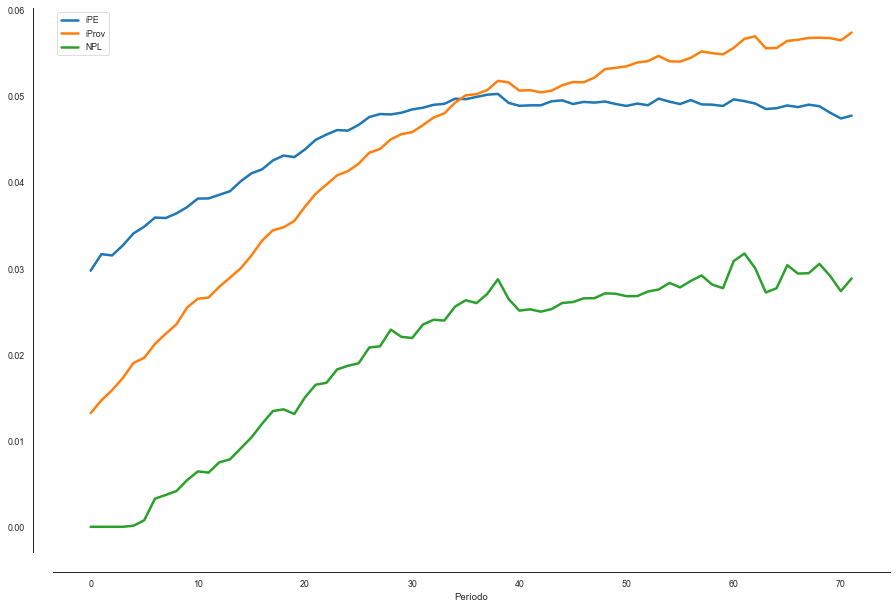

In [1032]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.color_palette("ch:s=.25,rot=-.25", as_cmap=True)

sns.set_style("white")
sns.set_context("paper")


#sns.set_style()
%matplotlib inline
fig, ax = plt.subplots(figsize=(15,10))
# data to create an example data frame
#df  = hst3[['iPE','iprov','inad90', 'perda_obs']]#[60:n-82]

# this is to plot the kde
sns.lineplot(data=df[:72], x='ref', y = 'iPE', label='iPE', linewidth=2.5)
sns.lineplot(data=df[:72], x='ref', y = 'iprov', label='iProv', linewidth=2.5)
sns.lineplot(data=df[:72], x='ref', y = 'inad90', label='NPL', linewidth=2.5)
#sns.lineplot(data=df[:120], x='ref', y = 'perda_obs', label='PO')

sns.despine(offset=20, trim=False);

#ax.axvline(72, ls='--', c='red')

# beautifying the labels
plt.xlabel('Período')
plt.ylabel('')
plt.show()

<Figure size 432x288 with 0 Axes>

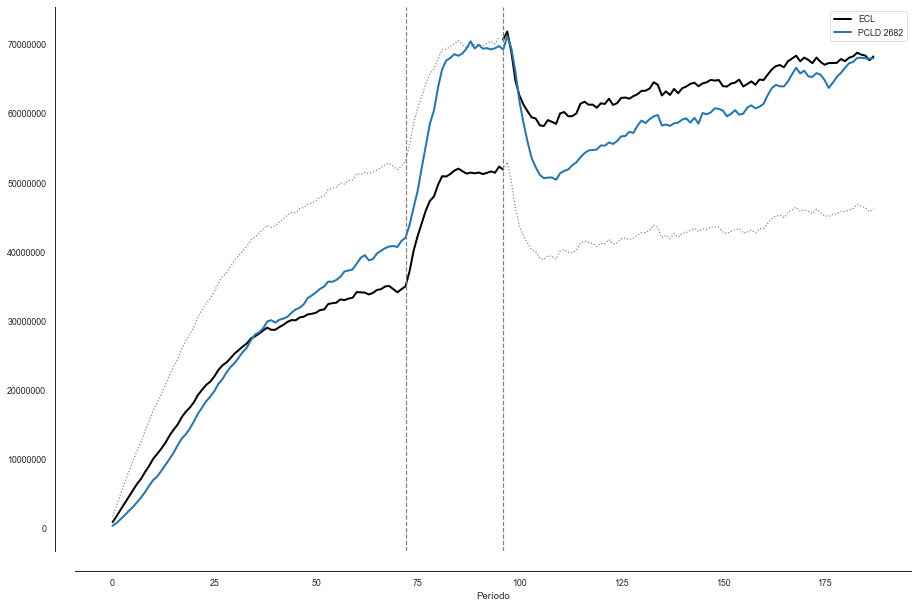

In [1005]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

sns.set_style("white")
sns.despine(left=True)

fig, ax1 = plt.subplots(figsize=(15,10))
# data to create an example data frame
#ax2 = ax1.twinx() 
# this is to plot the kde
sns.lineplot(data=hst3[0:97], x='ref', y = 'ecl', color='black', ax = ax1, label='ECL', linewidth = 2)
sns.lineplot(data=hst3[96:], x='ref', y = 'ecl', linestyle='dotted', color='grey', ax = ax1)
sns.lineplot(data=hst3[0:96], x='ref', y = 'ecl2', linestyle='dotted', color='grey', ax = ax1)
sns.lineplot(data=hst3[96:], x='ref', y = 'ecl2', color='black', ax = ax1, linewidth = 2)
sns.lineplot(data=hst2, x='ref', y = 'prov',  ax = ax1, label='PCLD 2682', linewidth = 2)
#sns.lineplot(data=df1[60:148][df1['ref_r'].between(60, 148, inclusive='both')], x='ref_r', y = 'pd', ax = ax2)

#sns.lineplot(data=hst2[60:156], x='ref', y = 'ecl3', linestyle='dashed', color='orange', ax = ax1)
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl4', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl5', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl6', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl7', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'prov', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'perda_att', linestyle='dashed')

plt.ticklabel_format(style='plain', axis='y')

ax1.axvline(72, ls='--', c='grey')
ax1.axvline(96, ls='--', c='grey')

sns.despine(offset=20, trim=False);

# beautifying the labels
plt.xlabel('Período')
plt.ylabel('')
plt.show()

In [927]:
sum(hst3['ecl'] - hst2['ecl'])

503100121.2850557

In [650]:
#carteira
pda = psql.read_sql('SELECT * FROM jpcosta.prd_anual', connection)

In [652]:
pda_lt = psql.read_sql('SELECT * FROM jpcosta.perda_lt_12', connection)

In [653]:
perda_ifrs = np.where(pda_lt['estagio'] == 1, pda_lt['perda_att_1'], pda_lt['perda_att_2'])

In [664]:
pda_lt['perda_ifrs'] = perda_ifrs

perda_ifrs9 = pda_lt[['ref', 'perda_ifrs', 'perda_att_2']].groupby('ref').sum()#.reset_index()
perda_ifrs9

,perda_ifrs,perda_att_2
ref,,
0,260532.39837214138,487004.3019555829
1,476745.9523496229,1192878.0500317984
2,846605.8901862217,1809833.4663358836
3,1288427.8638513505,2295048.5522831697
4,1782913.1668746239,2991073.405983892
...,...,...
183,0.0,0.0
184,0.0,0.0
185,0.0,0.0


In [672]:
hst2['npl'] = hst2['saldo_inad']/hst2['saldo']
hst2['iprov'] = hst2['prov']/hst2['saldo']
hst2['ipo_ifrs'] = perda_ifrs9['perda_ifrs']/hst2['saldo']
hst2['pe_ifrs'] = hst2['ecl4']/hst2['saldo']
hst2['pe_ifrs_atr'] = hst3['ecl4']/hst2['saldo'] 

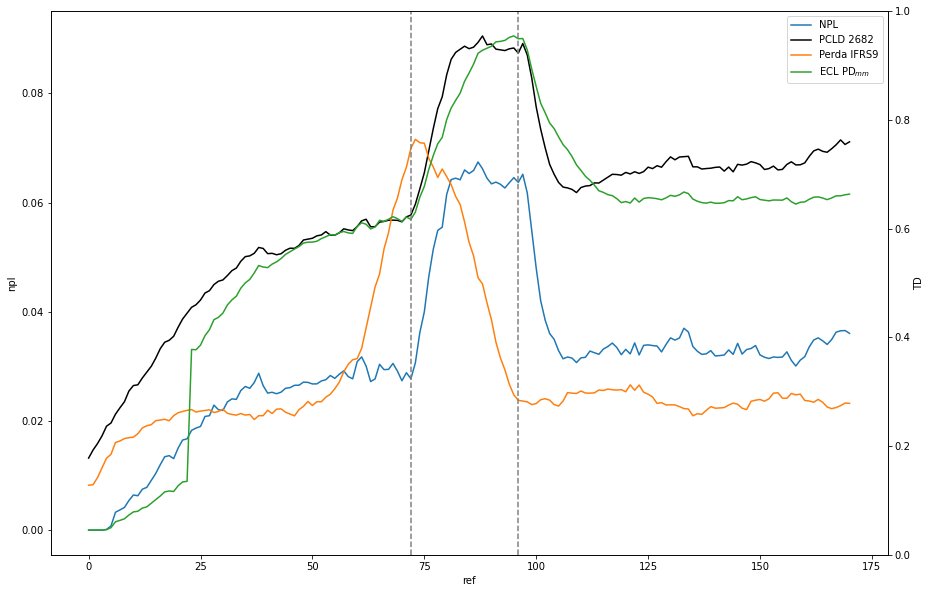

In [872]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax1 = plt.subplots(figsize=(15,10))
# data to create an example data frame
ax2 = ax1.twinx() 
# this is to plot the kde
#sns.lineplot(data=hst2[:171], x='ref', y = 'ecl', linestyle='dotted', color='grey', ax = ax1, label='ECL')
#sns.lineplot(data=hst2[:171], x='ref', y = 'ecl2', linestyle='dotted', color='grey', ax = ax1)
sns.lineplot(data=hst2[:171], x='ref', y = 'npl',ax = ax1, label='NPL')
sns.lineplot(data=hst2[:171], x='ref', y = 'iprov', color='black', ax = ax1, label='PCLD 2682')
#sns.lineplot(data=hst2[:171], x='ref', y = 'perda_att',  ax = ax1, label='Perda Obs.')
sns.lineplot(data=hst2[:171], x='ref', y = 'ipo_ifrs',  ax = ax1, label='Perda IFRS9')
#sns.lineplot(data=pda[:171], x='ref', y = 'perda_anual',  ax = ax1, label='Perda Anualizada')
sns.lineplot(data=hst2[:171], x='ref', y = 'pe_ifrs',  ax = ax1, label='ECL PD$_{mm}$')


#sns.lineplot(data=hst2[:171], x='ref', y = 'pe_ifrs_atr',  ax = ax1, label='ECL PD$_{mm} Atraso$')

#sns.lineplot(data=df1[60:148][df1['ref_r'].between(60, 148, inclusive='both')], x='ref_r', y = 'pd', ax = ax2)

#sns.lineplot(data=hst2[60:156], x='ref', y = 'ecl3', linestyle='dashed', color='orange', ax = ax1)
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl4', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl5', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl6', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl7', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'prov', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'perda_att', linestyle='dashed')


ax1.axvline(72, ls='--', c='grey')
ax1.axvline(96, ls='--', c='grey')


# beautifying the labels
plt.xlabel('Safra')
plt.ylabel('TD')
plt.show()

In [646]:
hst2

,saldo,saldo_inad,prov,ecl,ecl2,ecl3,ecl4,ecl5,ecl6,ecl7,perda_att,iprov,inad90,iPE1,iPE2,perda_obs
ref,,,,,,,,,,,,,,,,
0,31719896.089999996,0.0,418622.6267000001,1173692.0825406916,2272074.9144287026,0.0,0.0,0.0,0.0,0.0,487004.3019555829,0.013197477870426407,0.0,0.037001763158698034,0.07162933030997526,0.015353275451274752
1,57239367.480000004,0.0,840499.6466,2253101.463203283,4343898.255309211,0.0,0.0,0.0,0.0,0.0,1192878.0500317984,0.014683943649336775,0.0,0.039362794566004576,0.0758900464235041,0.020840168271401702
2,87855551.11999995,0.0,1394039.9052999995,3408838.402800445,6576721.650455948,0.0,0.0,0.0,0.0,0.0,1809833.4663358838,0.015867408348459525,0.0,0.03880048965994634,0.07485835062912473,0.020600103730086132
3,112806873.15,0.0,1948514.7453999997,4406940.096213455,8505289.53563749,0.0,0.0,0.0,0.0,0.0,2295048.5522831697,0.01727301440940613,0.0,0.039066237483185266,0.07539690887742234,0.02034493544760725
4,135366898.17000008,16671.93611087303,2576675.1506500016,5329433.254637122,10269802.050156837,9660.242570812272,9660.242570812272,9660.242570812272,9660.242570812272,9660.242570812272,2996063.9061543536,0.01903475063315769,0.00012316110021177878,0.03937028421781647,0.07586642073499787,0.022132913929901507
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,938290972.09,35058151.1990965,68048804.80590001,42256762.70486695,70058786.38229612,60593184.32939733,60171366.61548515,59191431.56579371,58864636.448385276,58650695.90021501,0.0,0.07252420286462356,0.03736383727641126,0.045035883283350744,0.0746663758537966,0.0
184,937570185.5399992,34539138.91165478,68066920.75355,42070278.25691926,69866561.4532783,59969617.69633363,60015032.59051689,59121425.073530756,58717658.654476866,58514475.74909758,0.0,0.07259928035611161,0.036838990237047425,0.04487160418042583,0.07451875340195276,0.0
185,937082995.8699999,33808226.19435,68004602.24989998,41764105.58242744,69572615.99372588,59482383.609621376,59706080.34677777,58940540.297378525,58456761.246113166,58264916.28671658,0.0,0.07257052208781532,0.0360781556632153,0.04456820342114213,0.0742438143690077,0.0


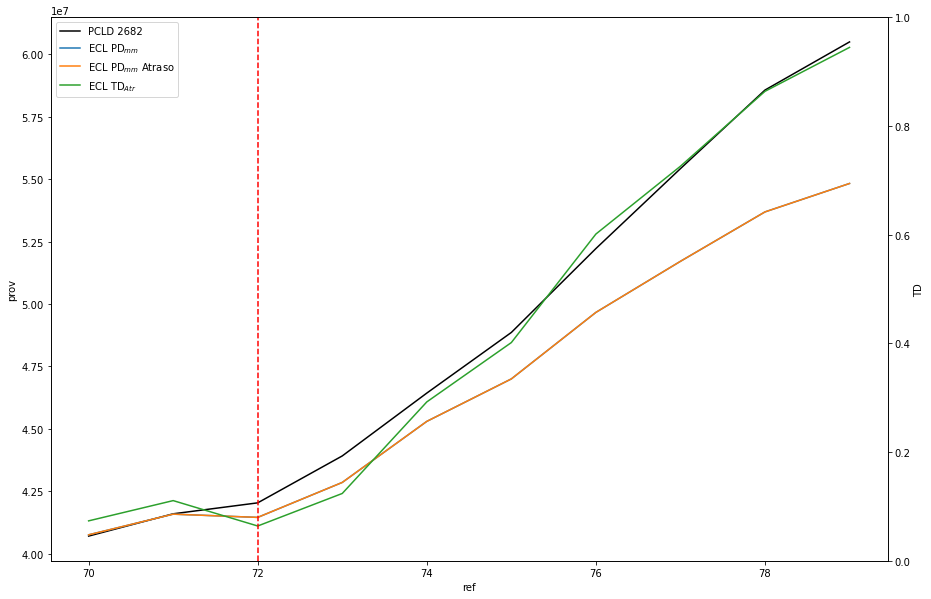

In [871]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax1 = plt.subplots(figsize=(15,10))
# data to create an example data frame
ax2 = ax1.twinx() 
# this is to plot the kde
#sns.lineplot(data=hst2[65:75], x='ref', y = 'ecl', linestyle='dotted', color='grey', ax = ax1, label='ECL')
#sns.lineplot(data=hst2[65:75], x='ref', y = 'ecl2', linestyle='dotted', color='grey', ax = ax1)
sns.lineplot(data=hst2[70:80], x='ref', y = 'prov', color='black', ax = ax1, label='PCLD 2682')
#sns.lineplot(data=hst2[65:80], x='ref', y = 'ecl3',  ax = ax1, label='ECL TD')
sns.lineplot(data=hst2[70:80], x='ref', y = 'ecl4',  ax = ax1, label='ECL PD$_{mm}$')

#sns.lineplot(data=hst3[68:80], x='ref', y = 'ecl3',  ax = ax1, label='ECL TD Atraso')
sns.lineplot(data=hst3[70:80], x='ref', y = 'ecl4',  ax = ax1, label='ECL PD$_{mm}$ Atraso')

sns.lineplot(data=hst3[70:80], x='ref', y = 'ecl3',  ax = ax1, label='ECL TD$_{Atr}$')
#sns.lineplot(data=hst2[70:80], x='ref', y = 'saldo_inad',  ax = ax2, label='NPL', color='green')
#sns.lineplot(data=df1[60:148][df1['ref_r'].between(60, 148, inclusive='both')], x='ref_r', y = 'pd', ax = ax2)

#sns.lineplot(data=hst2[60:156], x='ref', y = 'ecl3', linestyle='dashed', color='orange', ax = ax1)
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl4', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl5', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl6', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl7', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'prov', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'perda_att', linestyle='dashed')


ax1.axvline(72, ls='--', c='red')
#ax1.axvline(96, ls='--', c='grey')


# beautifying the labels
plt.xlabel('Safra')
plt.ylabel('TD')
plt.show()

### Despesa de PCLD

In [674]:
#carteira
prejuizo = psql.read_sql('SELECT * FROM jpcosta.prejuizo', connection)

In [697]:
prejuizo

,ref,perda_anual
0,13,2609.092245530808
1,14,61442.5182287199
2,15,82424.00422797173
3,16,90322.67849063003
4,17,131725.53078488837
...,...,...
183,196,2247108.9927315484
184,197,2048975.0396191336
185,198,2314796.611746055
186,199,2373484.6645400147


In [771]:
teste = ((prejuizo['ref'] - 1) - ((prejuizo['ref'] - 1) % 3)) + 3
prejuizo['ref'] = teste
preju_tri = prejuizo[['perda_anual', 'ref']].groupby('ref').sum()
preju_tri

,perda_anual
ref,
15,146475.61470222243
18,440550.872516608
21,614175.5280933037
24,1114111.1585434556
27,1424987.3735907236
...,...
189,7044477.035941297
192,7047098.615755434
195,6908648.767368186


In [755]:
PCLD_2682 = hst2.reset_index()[['ref','prov']]
PCLD_2682 = PCLD_2682[PCLD_2682['ref'] % 3 == 0]
PCLD_2682['delta_pcld'] = PCLD_2682['prov'] - PCLD_2682['prov'].shift(1)
PCLD_2682 = PCLD_2682.set_index('ref')[['delta_pcld']]
PCLD_2682

,delta_pcld
ref,
0,nan
3,1529892.1186999995
6,1867084.0228000002
9,2415254.4735499984
12,2140817.4917499963
...,...
174,251259.10809993
177,-1172865.526949972
180,2155518.2917500436


In [772]:
pe_ifrs = hst2.reset_index()[['ref','ecl4']]
pe_ifrs = pe_ifrs[pe_ifrs['ref'] % 3 == 0]
pe_ifrs['delta_pe_ifrs9mm'] = pe_ifrs['ecl4'] - pe_ifrs['ecl4'].shift(1)
pe_ifrs = pe_ifrs.set_index('ref')[['delta_pe_ifrs9mm']]
pe_ifrs

,delta_pe_ifrs9mm
ref,
0,nan
3,0.0
6,274589.7253337811
9,399927.57026781177
12,535140.8916943297
...,...
174,877922.3611416146
177,159802.98706115782
180,1450771.4385968596


In [945]:
PE_IFRS_st = np.where(hst3.reset_index()['ref'] < 96, hst3['ecl'], hst3['ecl2'])
hst3['PE_IFRS_st'] = PE_IFRS_st

pe_ifrs2 = hst3.reset_index()[['ref','PE_IFRS_st']]

pe_ifrs2 = pe_ifrs2[pe_ifrs2['ref'] % 3 == 0]
pe_ifrs2['delta_pe_ifrs9st'] = pe_ifrs2['PE_IFRS_st'] - pe_ifrs2['PE_IFRS_st'].shift(1)

pe_ifrs2 = pe_ifrs2.set_index('ref')[['delta_pe_ifrs9st']]

pe_ifrs2

,delta_pe_ifrs9st
ref,
0,nan
3,2742269.13775408
6,2767037.1350829345
9,2629120.176462396
12,2499007.2663537115
...,...
174,-290720.37368138134
177,-151222.18588474393
180,264044.9911893755


In [929]:
pe_ifrs3 = hst3.reset_index()[['ref','ecl4']]

pe_ifrs3 = pe_ifrs3[pe_ifrs3['ref'] % 3 == 0]
pe_ifrs3['delta_pe_ifrs9atr'] = pe_ifrs3['ecl4'] - pe_ifrs3['ecl4'].shift(1)
pe_ifrs3 = pe_ifrs3.set_index('ref')

pe_ifrs3 = pe_ifrs3[['delta_pe_ifrs9atr']]

pe_ifrs3

,delta_pe_ifrs9atr
ref,
0,nan
3,0.0
6,274589.7253337811
9,399927.57026781165
12,535140.8916943296
...,...
174,390744.101456061
177,219532.35421758145
180,654640.6156819314


In [952]:
PE_IFRS_st = np.where(hst2.reset_index()['ref'] < 96, hst2['ecl'], hst2['ecl2'])
hst2['PE_IFRS_st'] = PE_IFRS_st

pe_ifrs4 = hst2.reset_index()[['ref','PE_IFRS_st']]

pe_ifrs4 = pe_ifrs4[pe_ifrs4['ref'] % 3 == 0]
pe_ifrs4['delta_pe_ifrs9st2'] = pe_ifrs4['PE_IFRS_st'] - pe_ifrs4['PE_IFRS_st'].shift(1)

pe_ifrs4 = pe_ifrs4.set_index('ref')[['delta_pe_ifrs9st2']]

pe_ifrs4

,delta_pe_ifrs9st2
ref,
0,nan
3,3233248.0136727635
6,2869524.665400631
9,2779333.552280387
12,2511146.798834849
...,...
174,238695.51559253037
177,-414658.70361308753
180,979632.1493835598


In [932]:
pe_ifrs6 = hst3.reset_index()[['ref','ecl3']]

pe_ifrs6 = pe_ifrs6[pe_ifrs6['ref'] % 3 == 0]
pe_ifrs6['delta_pe_ifrs9atr_td'] = pe_ifrs6['ecl3'] - pe_ifrs6['ecl3'].shift(1)
pe_ifrs6 = pe_ifrs6.set_index('ref')

pe_ifrs6 = pe_ifrs6[['delta_pe_ifrs9atr_td']]

pe_ifrs6

,delta_pe_ifrs9atr_td
ref,
0,nan
3,0.0
6,274589.7253337811
9,399927.57026781165
12,10049561.008896641
...,...
174,834892.6506787539
177,-574634.2227668837
180,450619.109599106


In [1010]:
pe_ifrs7 = hst3.reset_index()[['ref','ecl6']]

pe_ifrs7 = pe_ifrs7[pe_ifrs7['ref'] % 3 == 0]
pe_ifrs7['delta_pe_ifrs924'] = pe_ifrs7['ecl6'] - pe_ifrs7['ecl6'].shift(1)
pe_ifrs7 = pe_ifrs7.set_index('ref')

pe_ifrs7 = pe_ifrs7[['delta_pe_ifrs924']]

pe_ifrs7

,delta_pe_ifrs924
ref,
0,nan
3,0.0
6,274589.7253337811
9,399927.57026781165
12,535140.8916943296
...,...
174,-65359.39408058673
177,-133714.14120370895
180,540413.9111738056


In [1011]:
base_desp = PCLD_2682.join(pe_ifrs2).join(pe_ifrs).join(pe_ifrs3).join(pe_ifrs4).join(pe_ifrs6).join(pe_ifrs7).join(preju_tri)
base_desp = base_desp.fillna(0)
base_desp

,delta_pcld,delta_pe_ifrs9st,delta_pe_ifrs9mm,delta_pe_ifrs9atr,delta_pe_ifrs9st2,delta_pe_ifrs9atr_td,delta_pe_ifrs924,perda_anual
ref,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1529892.1186999995,2742269.13775408,0.0,0.0,3233248.0136727635,0.0,0.0,0.0
6,1867084.0228000002,2767037.1350829345,274589.7253337811,274589.7253337811,2869524.665400631,274589.7253337811,274589.7253337811,0.0
9,2415254.4735499984,2629120.176462396,399927.57026781177,399927.57026781165,2779333.552280387,399927.57026781165,399927.57026781165,0.0
12,2140817.4917499963,2499007.2663537115,535140.8916943297,535140.8916943296,2511146.798834849,10049561.008896641,535140.8916943296,0.0
...,...,...,...,...,...,...,...,...
174,251259.10809993,-290720.37368138134,877922.3611416146,390744.101456061,238695.51559253037,834892.6506787539,-65359.39408058673,6903753.158836303
177,-1172865.526949972,-151222.18588474393,159802.98706115782,219532.35421758145,-414658.70361308753,-574634.2227668837,-133714.14120370895,6107461.390416968
180,2155518.2917500436,264044.9911893755,1450771.4385968596,654640.6156819314,979632.1493835598,450619.109599106,540413.9111738056,6021882.7588519575


In [1013]:
base_desp['d_2682'] = base_desp['perda_anual'] + base_desp['delta_pcld']
base_desp['d_ifrs'] = base_desp['perda_anual'] + base_desp['delta_pe_ifrs9st']
base_desp['d_ifrsmm'] = base_desp['perda_anual'] + base_desp['delta_pe_ifrs9mm']
base_desp['d_ifrsatr'] = base_desp['perda_anual'] + base_desp['delta_pe_ifrs9atr']
base_desp['d_ifrs2'] = base_desp['perda_anual'] + base_desp['delta_pe_ifrs9st2']
base_desp['d_ifrs_td'] = base_desp['perda_anual'] + base_desp['delta_pe_ifrs9atr_td']
base_desp['d_ifrs_24'] = base_desp['perda_anual'] + base_desp['delta_pe_ifrs924']

base_desp

,delta_pcld,delta_pe_ifrs9st,delta_pe_ifrs9mm,delta_pe_ifrs9atr,delta_pe_ifrs9st2,delta_pe_ifrs9atr_td,delta_pe_ifrs924,perda_anual,d_2682,d_ifrs,d_ifrsmm,d_ifrsatr,d_ifrs2,d_ifrs_td,d_ifrs_24
ref,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1529892.1186999995,2742269.13775408,0.0,0.0,3233248.0136727635,0.0,0.0,0.0,1529892.1186999995,2742269.13775408,0.0,0.0,3233248.0136727635,0.0,0.0
6,1867084.0228000002,2767037.1350829345,274589.7253337811,274589.7253337811,2869524.665400631,274589.7253337811,274589.7253337811,0.0,1867084.0228000002,2767037.1350829345,274589.7253337811,274589.7253337811,2869524.665400631,274589.7253337811,274589.7253337811
9,2415254.4735499984,2629120.176462396,399927.57026781177,399927.57026781165,2779333.552280387,399927.57026781165,399927.57026781165,0.0,2415254.4735499984,2629120.176462396,399927.57026781177,399927.57026781165,2779333.552280387,399927.57026781165,399927.57026781165
12,2140817.4917499963,2499007.2663537115,535140.8916943297,535140.8916943296,2511146.798834849,10049561.008896641,535140.8916943296,0.0,2140817.4917499963,2499007.2663537115,535140.8916943297,535140.8916943296,2511146.798834849,10049561.008896641,535140.8916943296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,251259.10809993,-290720.37368138134,877922.3611416146,390744.101456061,238695.51559253037,834892.6506787539,-65359.39408058673,6903753.158836303,7155012.266936233,6613032.785154922,7781675.519977918,7294497.260292364,7142448.674428834,7738645.809515057,6838393.764755717
177,-1172865.526949972,-151222.18588474393,159802.98706115782,219532.35421758145,-414658.70361308753,-574634.2227668837,-133714.14120370895,6107461.390416968,4934595.863466996,5956239.204532224,6267264.3774781255,6326993.744634549,5692802.68680388,5532827.167650084,5973747.249213259
180,2155518.2917500436,264044.9911893755,1450771.4385968596,654640.6156819314,979632.1493835598,450619.109599106,540413.9111738056,6021882.7588519575,8177401.050602001,6285927.750041333,7472654.197448817,6676523.374533889,7001514.908235517,6472501.8684510635,6562296.670025763


In [1014]:
base_desp_2 = base_desp.join(hst2[['saldo']])
base_desp_2['d_2682'] = base_desp_2['d_2682']/base_desp_2['saldo']
base_desp_2['d_ifrs'] = base_desp_2['d_ifrs']/base_desp_2['saldo']
base_desp_2['d_ifrs2'] = base_desp_2['d_ifrs2']/base_desp_2['saldo']
base_desp_2['d_ifrsmm'] = base_desp_2['d_ifrsmm']/base_desp_2['saldo']
base_desp_2['d_ifrsatr'] = base_desp_2['d_ifrsatr']/base_desp_2['saldo']
base_desp_2['d_ifrs_td'] = base_desp_2['d_ifrs_td']/base_desp_2['saldo']
base_desp_2['d_ifrs_24'] = base_desp_2['d_ifrs_24']/base_desp_2['saldo']

<Figure size 432x288 with 0 Axes>

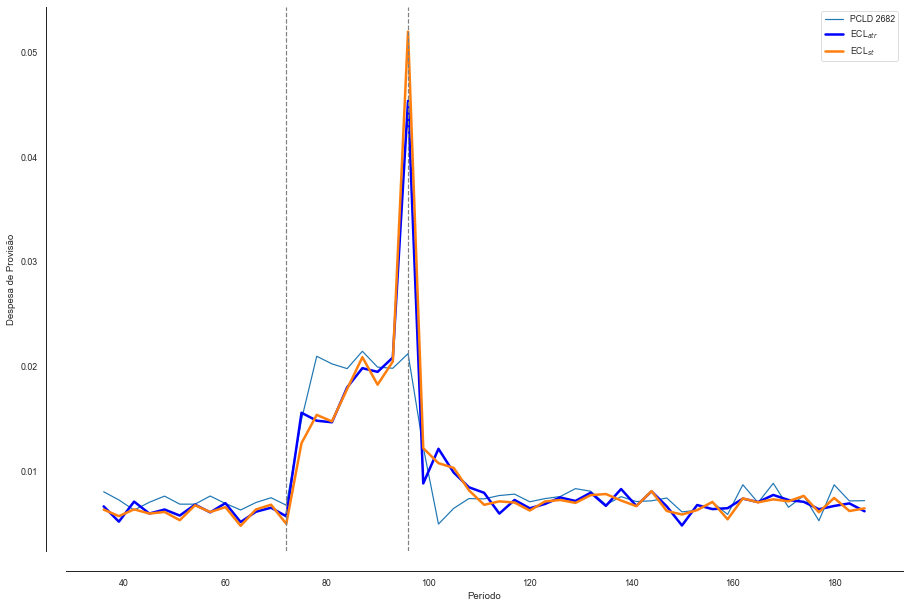

In [996]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

sns.set_style("white")
sns.despine(left=True)

fig, ax1 = plt.subplots(figsize=(15,10))
# data to create an example data frame
#ax2 = ax1.twinx() 
# this is to plot the kde

sns.lineplot(data=base_desp_2[12:], x='ref', y = 'd_2682', ax = ax1, label='PCLD 2682')

sns.lineplot(data=base_desp_2[12:], x='ref', y = 'd_ifrs',  ax = ax1, color='blue', label='ECL$_{atr}$', linewidth=2.5)

sns.lineplot(data=base_desp_2[12:], x='ref', y = 'd_ifrs2',  ax = ax1, label='ECL$_{st}$', linewidth=2.5)
#sns.lineplot(data=base_desp[12:], x='ref', y = 'd_ifrsmm',  ax = ax1, label='ECL$_{mm}$')

#sns.lineplot(data=base_desp[12:], x='ref', y = 'd_ifrsatr',  ax = ax1, label='ECL$_{atr}$')

#sns.lineplot(data=base_desp[12:], x='ref', y = 'd_ifrs_td',  ax = ax1, label='ECL$_TD{atr}$')

#sns.lineplot(data=base_desp[15:], x='ref', y = 'd_ifrslgd',  ax = ax1, label='ECL$_{lgd}$')

ax1.axvline(72, ls='--', c='grey')
ax1.axvline(96, ls='--', c='grey')

sns.despine(offset=20, trim=False);

# beautifying the labels
plt.xlabel('Período')
plt.ylabel('Despesa de Provisão')

plt.show()

<Figure size 432x288 with 0 Axes>

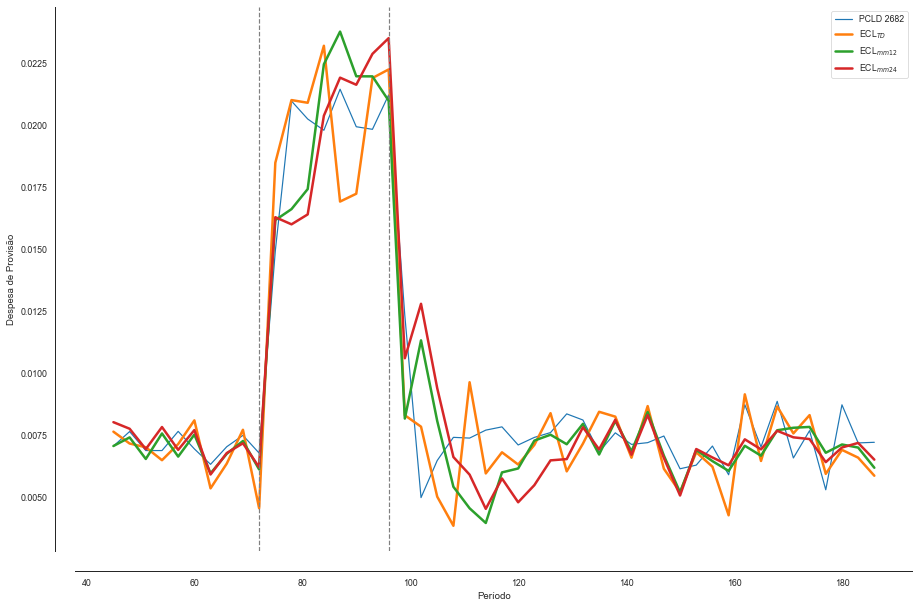

In [1025]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

sns.set_style("white")
sns.despine(left=True)

fig, ax1 = plt.subplots(figsize=(15,10))
# data to create an example data frame
#ax2 = ax1.twinx() 
# this is to plot the kde

sns.lineplot(data=base_desp_2[15:], x='ref', y = 'd_2682', ax = ax1, label='PCLD 2682')

#sns.lineplot(data=base_desp[12:], x='ref', y = 'd_ifrs',  ax = ax1, label='ECL$_{st}$')

#sns.lineplot(data=base_desp_2[12:], x='ref', y = 'd_ifrsmm',  ax = ax1, label='ECL$_{mm}$')

sns.lineplot(data=base_desp_2[15:], x='ref', y = 'd_ifrs_td',  ax = ax1, label='ECL$_{TD}$', linewidth=2.5)

sns.lineplot(data=base_desp_2[15:], x='ref', y = 'd_ifrsatr',  ax = ax1, label='ECL$_{mm12}$', linewidth=2.5)

sns.lineplot(data=base_desp_2[15:], x='ref', y = 'd_ifrs_24',  ax = ax1, label='ECL$_{mm24}$', linewidth=2.5)

#sns.lineplot(data=base_desp[15:], x='ref', y = 'd_ifrslgd',  ax = ax1, label='ECL$_{lgd}$')

ax1.axvline(72, ls='--', c='grey')
ax1.axvline(96, ls='--', c='grey')

sns.despine(offset=20, trim=False);

# beautifying the labels
plt.xlabel('Período')
plt.ylabel('Despesa de Provisão')

plt.show()

In [1018]:
print(base_desp_2['d_ifrs_td'].var()/base_desp_2['d_ifrs_td'].mean())
print(base_desp_2['d_ifrsatr'].var()/base_desp_2['d_ifrsatr'].mean())
print(base_desp_2['d_ifrs_24'].var()/base_desp_2['d_ifrs_td'].mean())


0.004332112912895301
0.0037244148034905745
0.0038910922116196507


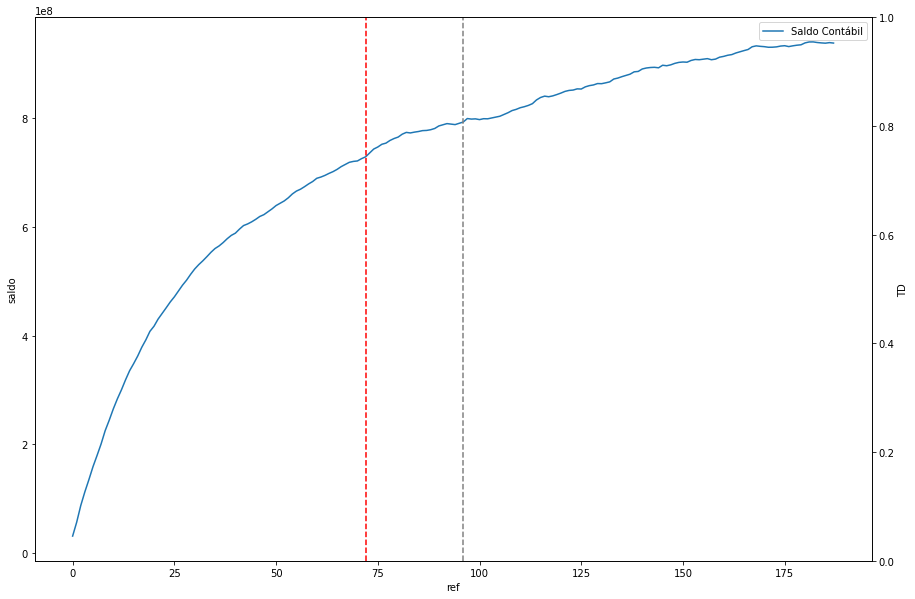

In [846]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.ticklabel_format(style='plain', axis='y',useOffset=False)

%matplotlib inline

fig, ax1 = plt.subplots(figsize=(15,10))
# data to create an example data frame
ax2 = ax1.twinx() 
# this is to plot the kde

sns.lineplot(data=hst2, x='ref', y = 'saldo', ax = ax1, label='Saldo Contábil')

ax1.axvline(72, ls='--', c='red')
ax1.axvline(96, ls='--', c='grey')


# beautifying the labels
plt.xlabel('Safra')
plt.ylabel('TD')
plt.show()

In [852]:
hst2[96:97][['saldo']]

,saldo
ref,
96,792267349.7599996


In [856]:
base_desp[base_desp.index == 96][['d_ifrs']]

,delta_pcld,delta_pe_ifrs9st,delta_pe_ifrs9mm,delta_pe_ifrs9atr,delta_pe_ifrs9lgd,perda_anual,d_2682,d_ifrs,d_ifrsmm,d_ifrsatr,d_ifrslgd
ref,,,,,,,,,,,
96,-33707.48584996164,24292855.70927299,582468.0255317092,-218463.97252954543,2255182.334556125,16848247.914073788,16814540.428223826,41141103.623346776,17430715.939605497,16629783.941544242,19103430.248629913
